Đọc dữ liệu

In [ ]:
from google.colab import files


uploaded = files.upload()

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data.csv


Import các thư viện cần thiết

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Đọc dữ liệu

In [ ]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv', delimiter = ',', encoding = 'utf-8')

In [ ]:
df.head(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Thông tin về dữ liệu

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


Drop cột "id" do không cần thiết

In [ ]:
df = df.drop('id', axis=1)

Có một số dòng dữ liệu của cột "bmi" bị thiếu. Do đó ta xử lý dữ liệu bị thiếu bằng cách fill bằng Trung vị (Median)

In [ ]:
df['bmi'] = df['bmi'].fillna(round (df['bmi'].median(), 2))
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


Thống kê dữ liệu định lượng

In [ ]:
round(df.describe(exclude = 'object'), 2)

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.00,5110.0,5110.00,5110.00,5110.00,5110.00
mean,43.23,0.1,0.05,106.15,28.86,0.05
std,22.61,0.3,0.23,45.28,7.70,0.22
min,0.08,0.0,0.00,55.12,10.30,0.00
25%,25.00,0.0,0.00,77.24,23.80,0.00
50%,45.00,0.0,0.00,91.88,28.10,0.00
75%,61.00,0.0,0.00,114.09,32.80,0.00
max,82.00,1.0,1.00,271.74,97.60,1.00


Thống kê dữ liệu định tính

In [ ]:
round(df.describe(exclude = ['float', 'int64']),2)

,gender,ever_married,work_type,Residence_type,smoking_status
count,5110,5110,5110,5110,5110
unique,3,2,5,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2994,3353,2925,2596,1892


In [ ]:
print(df['gender'].value_counts())

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


Trong bộ dữ liệu này có 1 trường hợp là 'Other'.
Vì số lượng quá nhỏ (1 mẫu), ta có thể loại bỏ để tránh nhiễu khi phân tích dữ liệu

In [ ]:
df = df[df['gender'] != 'Other']

Kiểm tra dữ liệu trùng lặp

In [ ]:
duplicates = df.duplicated().sum()
print(duplicates)

0


## **Tiến hành phân tích mô tả (EDA)**

Số lượng người bị đột quỵ và không bị

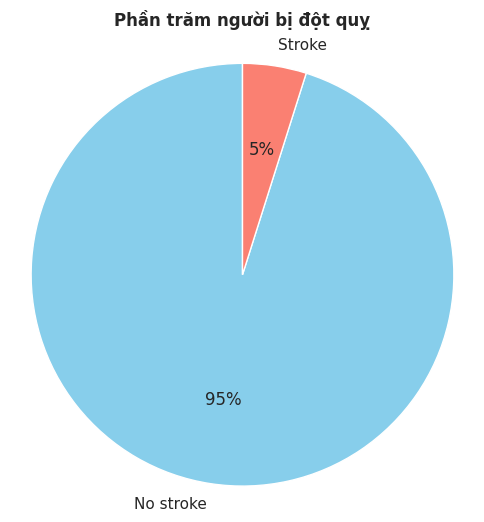

In [ ]:
stroke_counts = df['stroke'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(stroke_counts,
        labels=['No stroke', 'Stroke'],
        autopct='%1.f%%',
        startangle=90,
        colors=['skyblue', 'salmon'])

plt.title('Phần trăm người bị đột quỵ', weight='bold', pad='13')
plt.axis('equal')
plt.show()

In [ ]:
df_stroke = df[df['stroke'] == 1]
df_no_stroke = df[df['stroke'] == 0]
print(f"Số lượng bệnh nhân đột quỵ: {len(df_stroke)}")
print(f"Số lượng bệnh nhân không đột quỵ: {len(df_no_stroke)}")

Số lượng bệnh nhân đột quỵ: 249
Số lượng bệnh nhân không đột quỵ: 4860


# **Tiến hành phân tích dữ liệu của những người bị đột quỵ**

Dữ liệu về độ tuổi (Age)

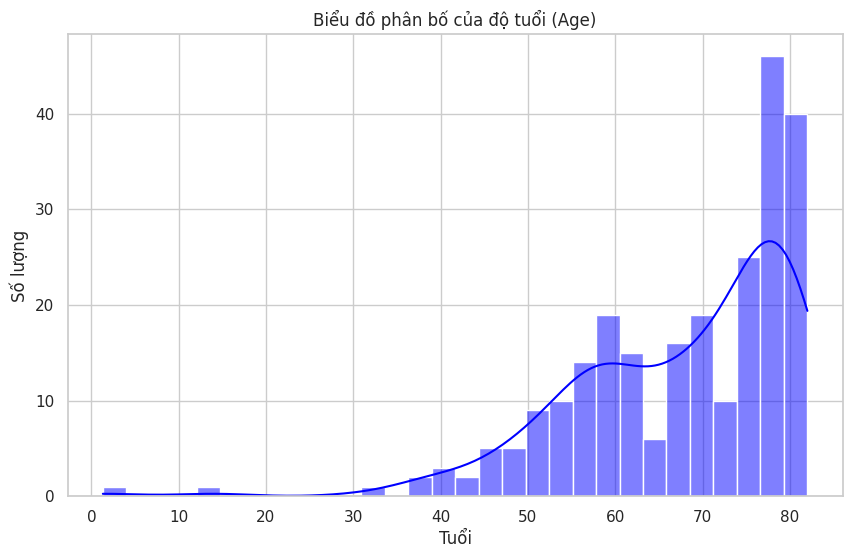

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_stroke['age'], kde=True, color='blue', bins=30)
plt.title('Biểu đồ phân bố của độ tuổi (Age)')
plt.xlabel('Tuổi')
plt.ylabel('Số lượng')
plt.show()

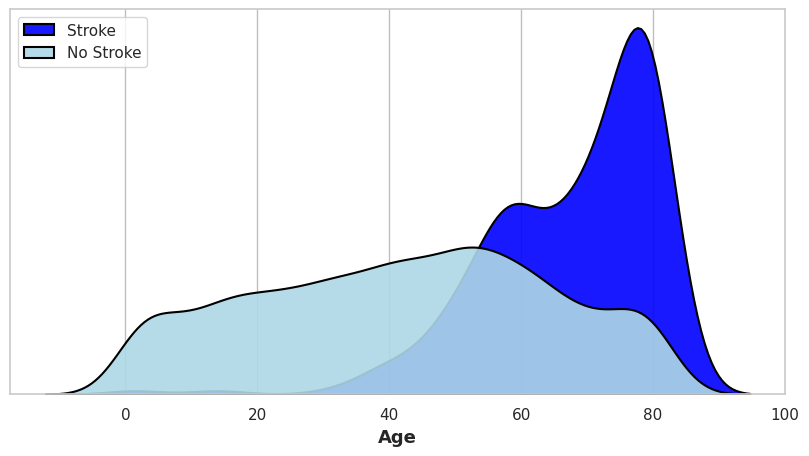

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(df_stroke['age'], ax=ax, color='blue', fill=True, alpha=0.9, linewidth=1.5, ec='black', label='Stroke')
sns.kdeplot(df_no_stroke['age'], ax=ax, color='lightblue', fill=True, alpha=0.9, linewidth=1.5, ec='black', label='No Stroke')

ax.set_xlabel('Age', fontsize=13, fontweight='bold')
ax.get_yaxis().set_visible(False)
ax.grid(axis='x', color='gray', alpha=0.5)

plt.legend()
plt.show()

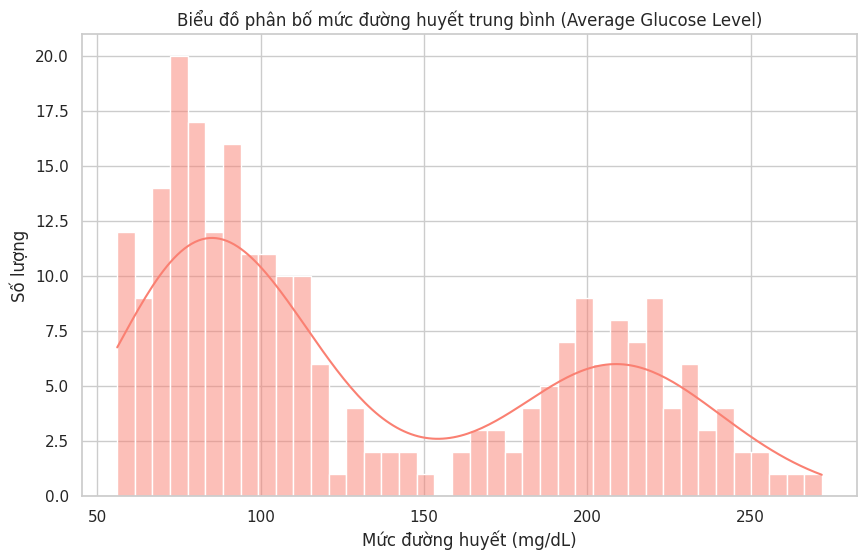

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_stroke['avg_glucose_level'], kde=True, color='salmon', bins=40)
plt.title('Biểu đồ phân bố mức đường huyết trung bình (Average Glucose Level)')
plt.xlabel('Mức đường huyết (mg/dL)')
plt.ylabel('Số lượng')
plt.show()

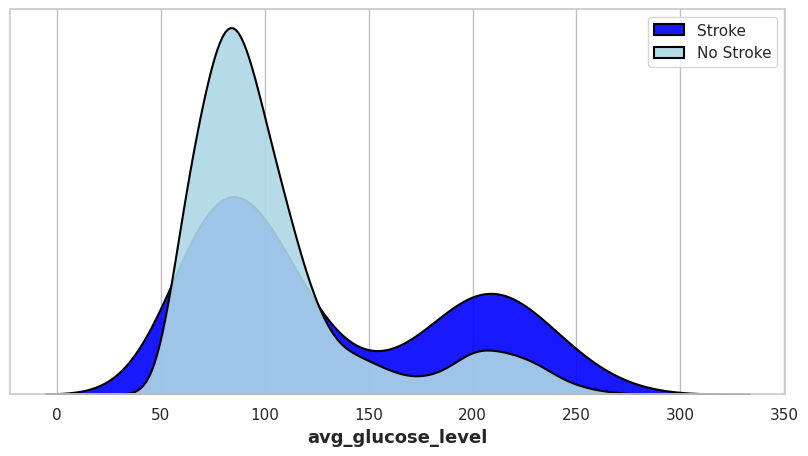

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(df_stroke['avg_glucose_level'], ax=ax, color='blue', fill=True, alpha=0.9, linewidth=1.5, ec='black', label='Stroke')
sns.kdeplot(df_no_stroke['avg_glucose_level'], ax=ax, color='lightblue', fill=True, alpha=0.9, linewidth=1.5, ec='black', label='No Stroke')

ax.set_xlabel('avg_glucose_level', fontsize=13, fontweight='bold')
ax.get_yaxis().set_visible(False)
ax.grid(axis='x', color='gray', alpha=0.5)

plt.legend()
plt.show()

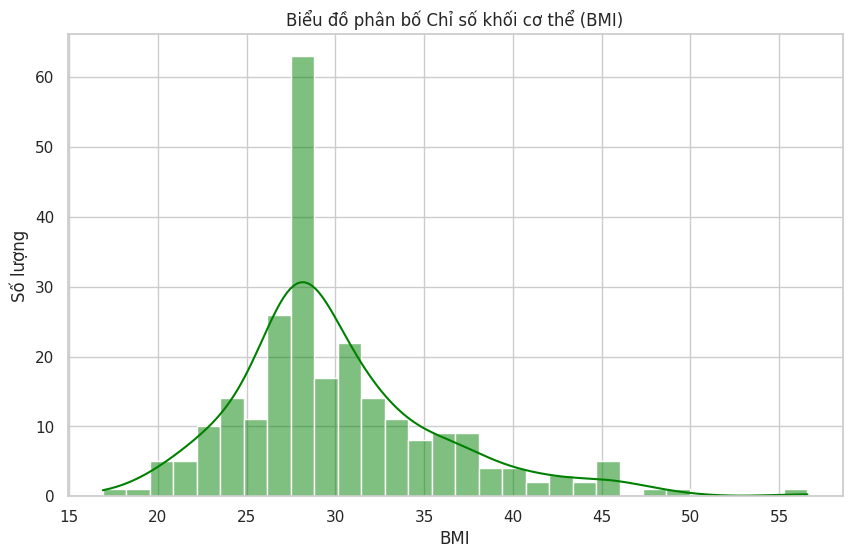

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_stroke['bmi'], kde=True, color='green', bins=30)
plt.title('Biểu đồ phân bố Chỉ số khối cơ thể (BMI)')
plt.xlabel('BMI')
plt.ylabel('Số lượng')
plt.show()

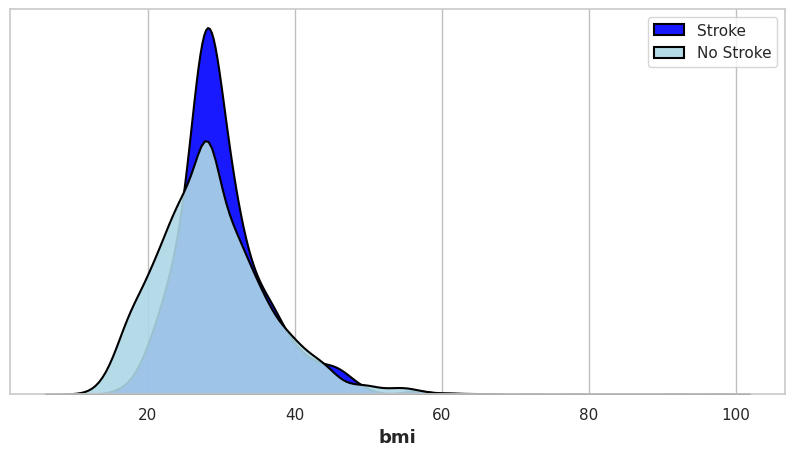

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(df_stroke['bmi'], ax=ax, color='blue', fill=True, alpha=0.9, linewidth=1.5, ec='black', label='Stroke')
sns.kdeplot(df_no_stroke['bmi'], ax=ax, color='lightblue', fill=True, alpha=0.9, linewidth=1.5, ec='black', label='No Stroke')

ax.set_xlabel('bmi', fontsize=13, fontweight='bold')
ax.get_yaxis().set_visible(False)
ax.grid(axis='x', color='gray', alpha=0.5)

plt.legend()
plt.show()

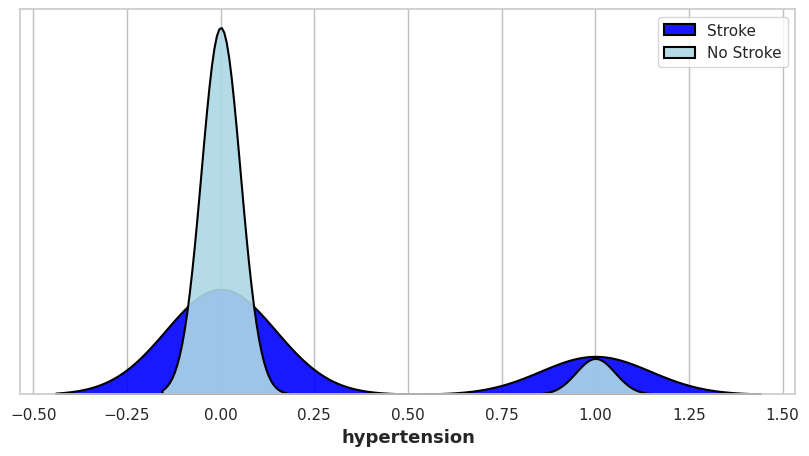

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(df_stroke['hypertension'], ax=ax, color='blue', fill=True, alpha=0.9, linewidth=1.5, ec='black', label='Stroke')
sns.kdeplot(df_no_stroke['hypertension'], ax=ax, color='lightblue', fill=True, alpha=0.9, linewidth=1.5, ec='black', label='No Stroke')

ax.set_xlabel('hypertension', fontsize=13, fontweight='bold')
ax.get_yaxis().set_visible(False)
ax.grid(axis='x', color='gray', alpha=0.5)

plt.legend()
plt.show()

In [ ]:
df['stroke_label'] = df['stroke'].map({0: 'No stroke', 1: 'Stroke'})

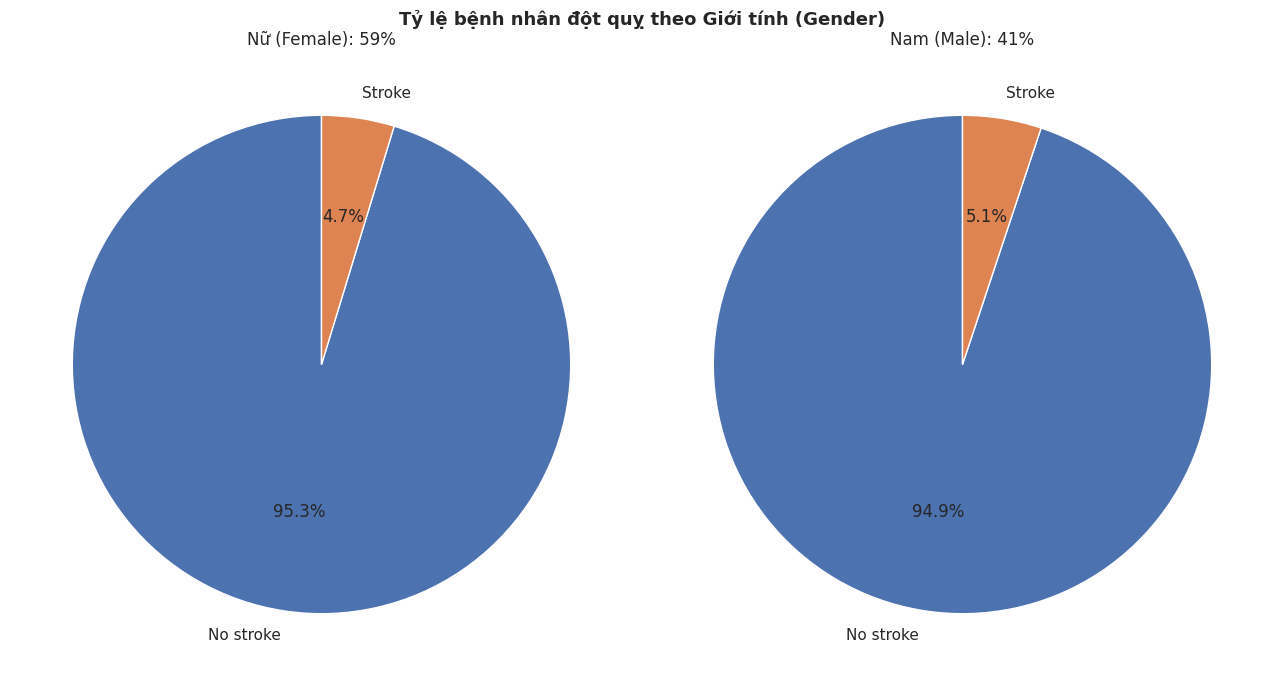

In [ ]:
female = df['gender'].value_counts().values[0]
male =  df['gender'].value_counts().values[1]

female_per = int(round(female/(female+male) * 100, 0))
male_per = int(round(male/(female+male)* 100, 0))

categories = sorted(df['gender'].unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
fig.suptitle('Tỷ lệ bệnh nhân đột quỵ theo Giới tính (Gender)', fontsize=13, fontweight='bold')

subset_female = df[df['gender'] == 'Female']['stroke_label'].value_counts()
axes[0].pie(subset_female, labels=subset_female.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title(f'Nữ (Female): {female_per}%')

subset_male = df[df['gender'] == 'Male']['stroke_label'].value_counts()
axes[1].pie(subset_male, labels=subset_male.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'Nam (Male): {male_per}%')

plt.tight_layout()
plt.show()

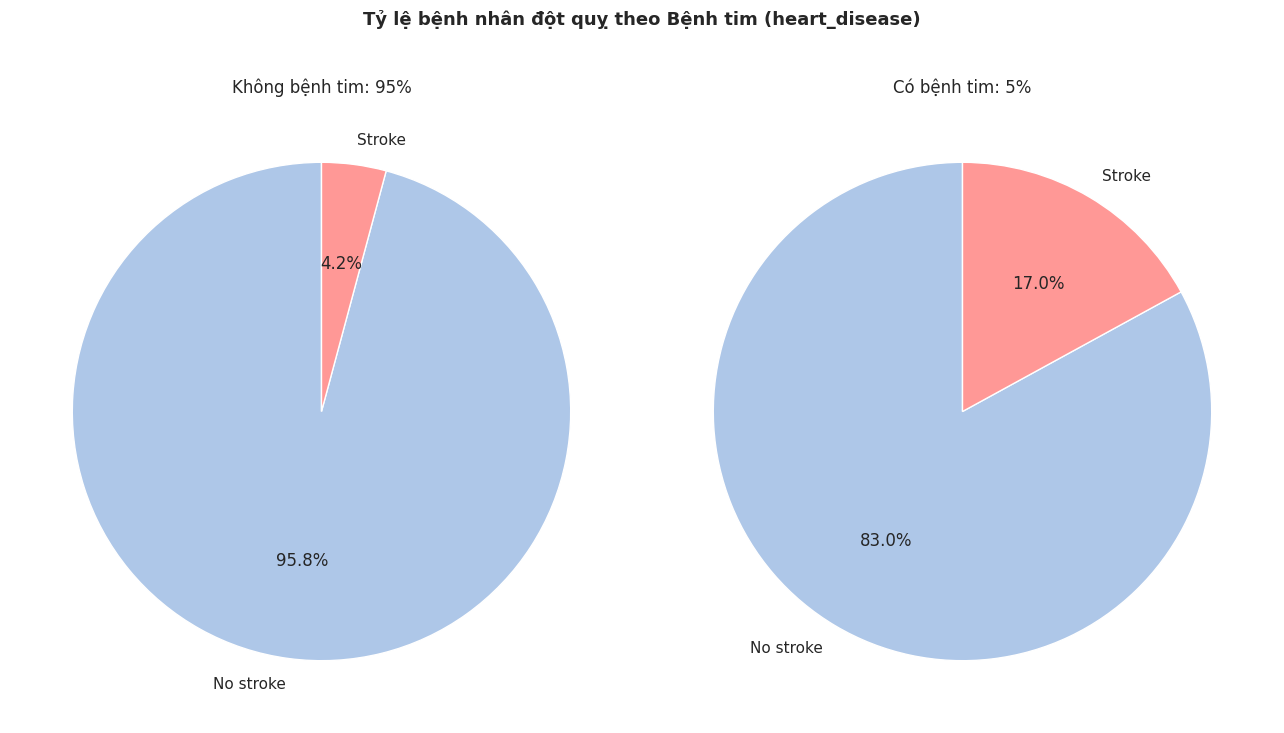

In [ ]:
hd_no = df['heart_disease'].value_counts()[0]
hd_yes = df['heart_disease'].value_counts()[1]
total = hd_no + hd_yes

hd_no_per = int(round(hd_no/total * 100, 0))
hd_yes_per = int(round(hd_yes/total * 100, 0))

fig, axes = plt.subplots(1, 2, figsize=(13, 8))
fig.suptitle('Tỷ lệ bệnh nhân đột quỵ theo Bệnh tim (heart_disease)', fontsize=13, fontweight='bold')

subset_no = df[df['heart_disease'] == 0]['stroke_label'].value_counts()
axes[0].pie(subset_no, labels=subset_no.index, autopct='%1.1f%%', startangle=90, colors=['#aec7e8', '#ff9896'])
axes[0].set_title(f'Không bệnh tim: {hd_no_per}%')

subset_yes = df[df['heart_disease'] == 1]['stroke_label'].value_counts()
axes[1].pie(subset_yes, labels=subset_yes.index, autopct='%1.1f%%', startangle=90, colors=['#aec7e8', '#ff9896'])
axes[1].set_title(f'Có bệnh tim: {hd_yes_per}%')

plt.tight_layout()
plt.show()

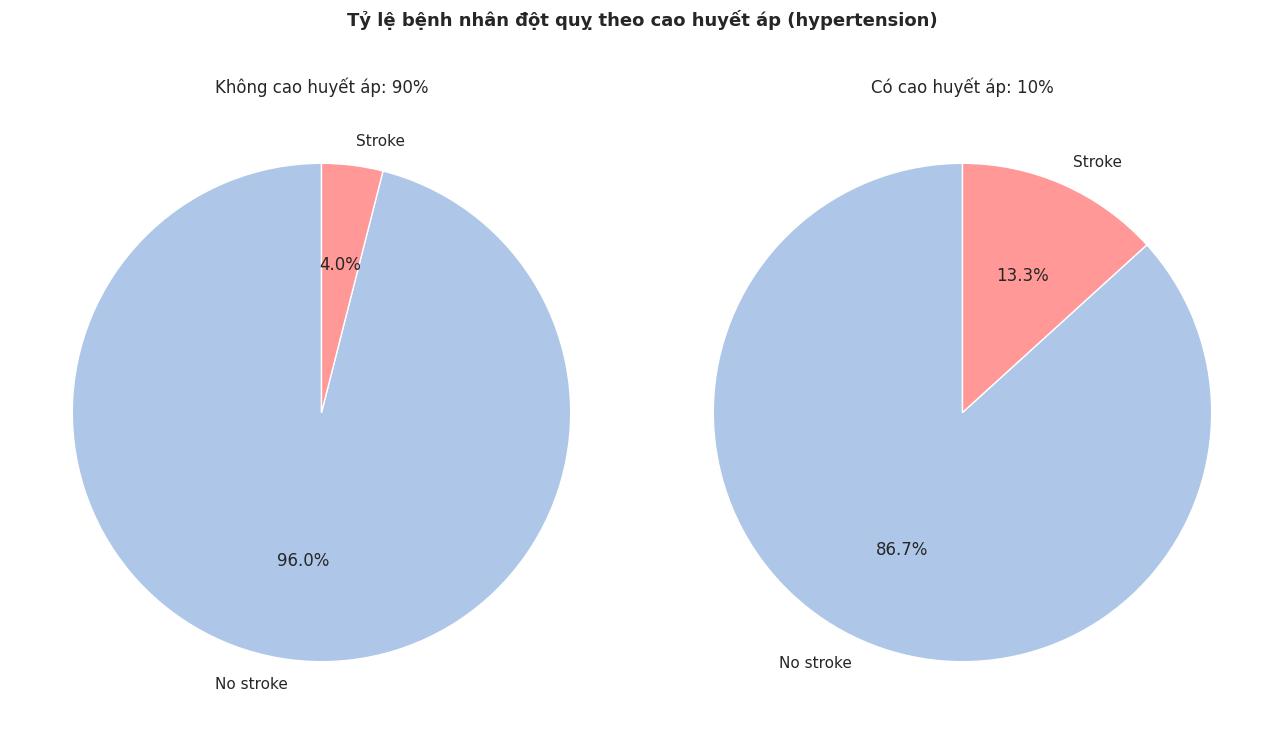

In [ ]:
ht_no = df['hypertension'].value_counts()[0]
ht_yes = df['hypertension'].value_counts()[1]
total = ht_no + ht_yes

ht_no_per = int(round(ht_no/total * 100, 0))
ht_yes_per = int(round(ht_yes/total * 100, 0))

fig, axes = plt.subplots(1, 2, figsize=(13, 8))
fig.suptitle('Tỷ lệ bệnh nhân đột quỵ theo cao huyết áp (hypertension)', fontsize=13, fontweight='bold')

subset_no_ht = df[df['hypertension'] == 0]['stroke_label'].value_counts()
axes[0].pie(subset_no_ht, labels=subset_no_ht.index, autopct='%1.1f%%', startangle=90, colors=['#aec7e8', '#ff9896'])
axes[0].set_title(f'Không cao huyết áp: {ht_no_per}%')

subset_yes_ht = df[df['hypertension'] == 1]['stroke_label'].value_counts()
axes[1].pie(subset_yes_ht, labels=subset_yes_ht.index, autopct='%1.1f%%', startangle=90, colors=['#aec7e8', '#ff9896'])
axes[1].set_title(f'Có cao huyết áp: {ht_yes_per}%')

plt.tight_layout()
plt.show()

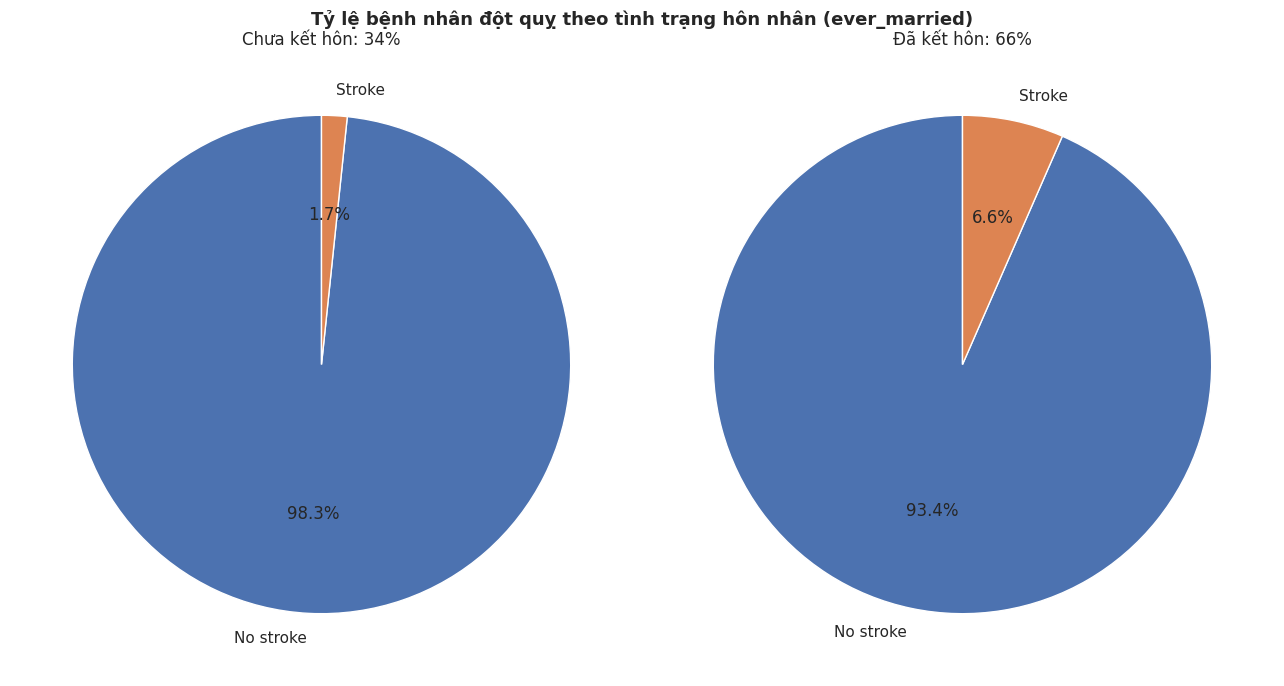

In [ ]:
categories = sorted(df['ever_married'].unique())

not_married = df['ever_married'].value_counts().values[0]
married =  df['ever_married'].value_counts().values[1]

not_married_per = int(round(married/(married+not_married) * 100, 0))
married_per = int(round(not_married/(married+not_married)* 100, 0))

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
fig.suptitle('Tỷ lệ bệnh nhân đột quỵ theo tình trạng hôn nhân (ever_married)', fontsize=13, fontweight='bold')

subset_no = df[df['ever_married'] == 'No']['stroke_label'].value_counts()
axes[0].pie(subset_no, labels=subset_no.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title(f'Chưa kết hôn: {not_married_per}%')

subset_yes = df[df['ever_married'] == 'Yes']['stroke_label'].value_counts()
axes[1].pie(subset_yes, labels=subset_yes.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'Đã kết hôn: {married_per}%')

plt.tight_layout()
plt.show()

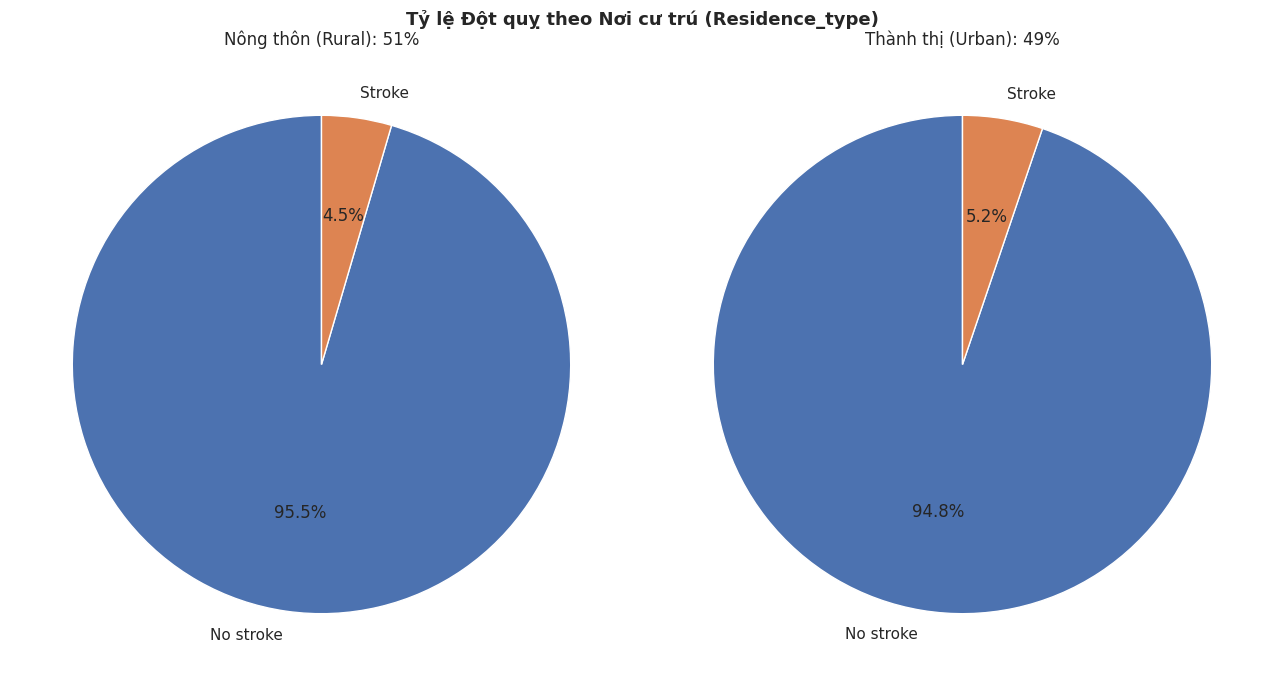

In [ ]:
categories = sorted(df['Residence_type'].unique())

urban = df['Residence_type'].value_counts().values[0]
rural =  df['Residence_type'].value_counts().values[1]

rural_per = int(round(rural/(rural+urban) * 100, 0))
urban_per = int(round(urban/(rural+urban)* 100, 0))

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
fig.suptitle('Tỷ lệ Đột quỵ theo Nơi cư trú (Residence_type)', fontsize=13, fontweight='bold')

subset_rural = df[df['Residence_type'] == 'Rural']['stroke_label'].value_counts()
axes[0].pie(subset_rural, labels=subset_rural.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title(f'Nông thôn (Rural): {urban_per}%')

subset_urban = df[df['Residence_type'] == 'Urban']['stroke_label'].value_counts()
axes[1].pie(subset_urban, labels=subset_urban.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'Thành thị (Urban): {rural_per}%')

plt.tight_layout()
plt.show()

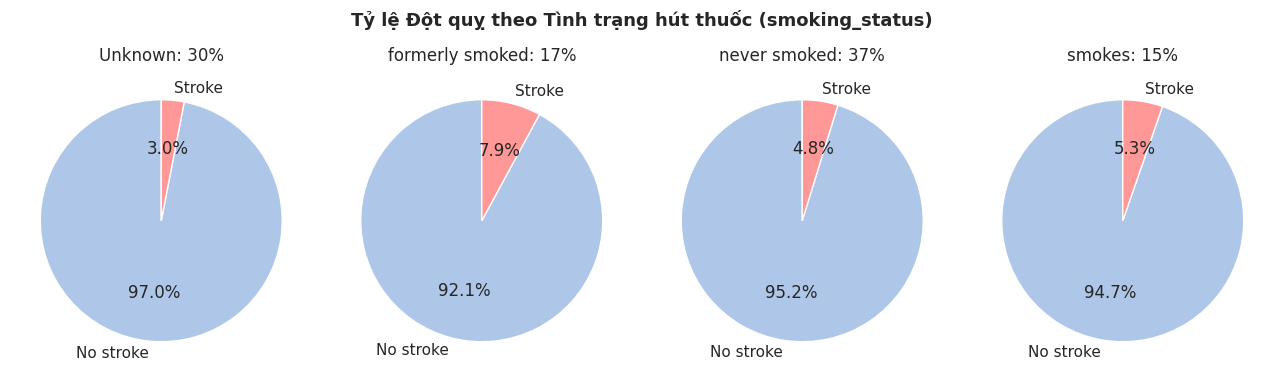

In [ ]:
categories = sorted(df['smoking_status'].unique())
total_samples = len(df)

fig, axes = plt.subplots(1, 4, figsize=(13, 4))
fig.suptitle('Tỷ lệ Đột quỵ theo Tình trạng hút thuốc (smoking_status)', fontsize=13, fontweight='bold')

for i, cat in enumerate(categories):
    count = len(df[df['smoking_status'] == cat])
    percent = int(round(count / total_samples * 100, 0))

    subset = df[df['smoking_status'] == cat]['stroke_label'].value_counts()

    axes[i].pie(subset, labels=subset.index, autopct='%1.1f%%', startangle=90, colors=['#aec7e8', '#ff9896'])

    axes[i].set_title(f'{cat}: {percent}%')

plt.tight_layout()
plt.show()

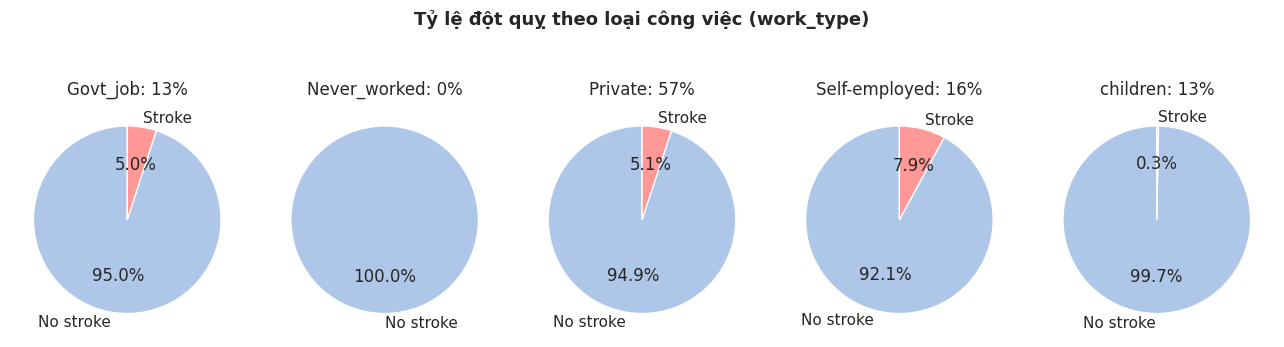

In [ ]:
categories = sorted(df['work_type'].unique())
total_samples = len(df)

fig, axes = plt.subplots(1, 5, figsize=(13, 4))
fig.suptitle('Tỷ lệ đột quỵ theo loại công việc (work_type)', fontsize=13, fontweight='bold')

for i, cat in enumerate(categories):
    count = len(df[df['work_type'] == cat])
    percent = int(round(count / total_samples * 100, 0))

    subset = df[df['work_type'] == cat]['stroke_label'].value_counts()

    axes[i].pie(subset, labels=subset.index, autopct='%1.1f%%', startangle=90, colors=['#aec7e8', '#ff9896'])

    axes[i].set_title(f'{cat}: {percent}%')

plt.tight_layout()
plt.show()

In [ ]:
filtered_data = df[(df['work_type'] == 'children') & (df['stroke'] == 1)]

count = len(filtered_data)
ages = filtered_data['age'].tolist()

print(f"Số lượng trẻ em bị đột quỵ (work_type='children' và stroke=1): {count}")
print(f"Độ tuổi: {ages}")

Số lượng trẻ em bị đột quỵ (work_type='children' và stroke=1): 2
Độ tuổi: [1.32, 14.0]


Phân bố theo giới tính và hôn nhân

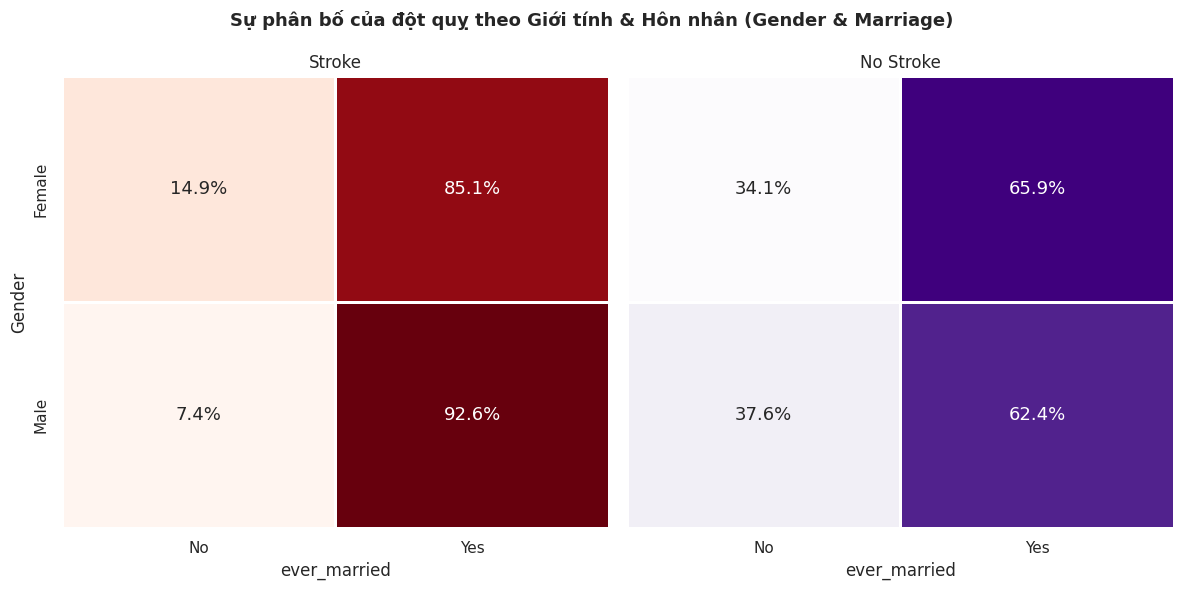

In [ ]:
stroke_ct = pd.crosstab(df_stroke['gender'], df_stroke['ever_married'], normalize='index')
no_stroke_ct = pd.crosstab(df_no_stroke['gender'], df_no_stroke['ever_married'], normalize='index')

fig, axes = plt.subplots(1, 2)
fig.suptitle('Sự phân bố của đột quỵ theo Giới tính & Hôn nhân (Gender & Marriage)', fontsize=13, fontweight='bold')

sns.heatmap(stroke_ct, annot=True, fmt='.1%', cmap='Reds', ax=axes[0],
            cbar=False, linewidths=1, annot_kws={"size": 13})
axes[0].set_title('Stroke')
axes[0].set_ylabel('Gender')
axes[0].set_xlabel('ever_married')

sns.heatmap(no_stroke_ct, annot=True, fmt='.1%', cmap='Purples', ax=axes[1],
            cbar=False, linewidths=1, annot_kws={"size": 13})
axes[1].set_title('No Stroke')
axes[1].set_ylabel('')
axes[1].set_yticks([])
axes[1].set_xlabel('ever_married')

plt.tight_layout()
plt.show()

Phân bố theo giới tính và tình trạng hút thuốc

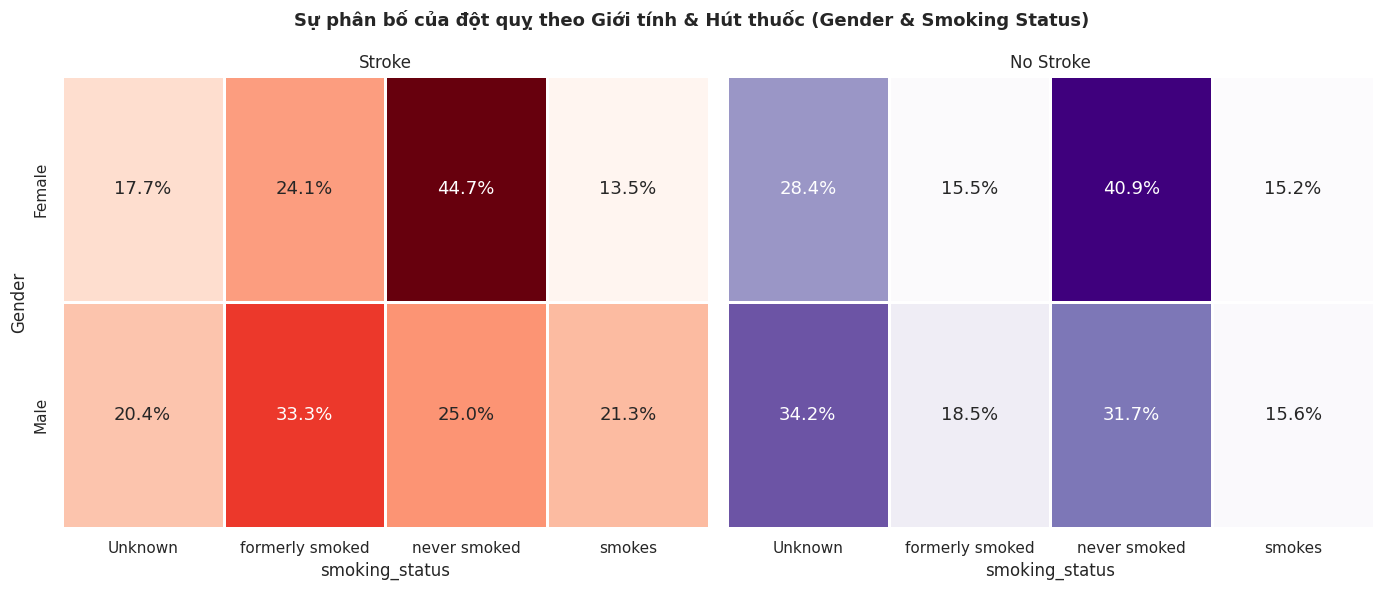

In [ ]:
stroke_ct_smoke = pd.crosstab(df_stroke['gender'], df_stroke['smoking_status'], normalize='index')
no_stroke_ct_smoke = pd.crosstab(df_no_stroke['gender'], df_no_stroke['smoking_status'], normalize='index')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Sự phân bố của đột quỵ theo Giới tính & Hút thuốc (Gender & Smoking Status)', fontsize=13, fontweight='bold')

sns.heatmap(stroke_ct_smoke, annot=True, fmt='.1%', cmap='Reds', ax=axes[0],
            cbar=False, linewidths=1, annot_kws={"size": 13})
axes[0].set_title('Stroke')
axes[0].set_ylabel('Gender')
axes[0].set_xlabel('smoking_status')

sns.heatmap(no_stroke_ct_smoke, annot=True, fmt='.1%', cmap='Purples', ax=axes[1],
            cbar=False, linewidths=1, annot_kws={"size": 13})
axes[1].set_title('No Stroke')
axes[1].set_ylabel('')
axes[1].set_yticks([])
axes[1].set_xlabel('smoking_status')

plt.tight_layout()
plt.show()

Phân bố theo tình trạng cao huyết áp và bệnh tim

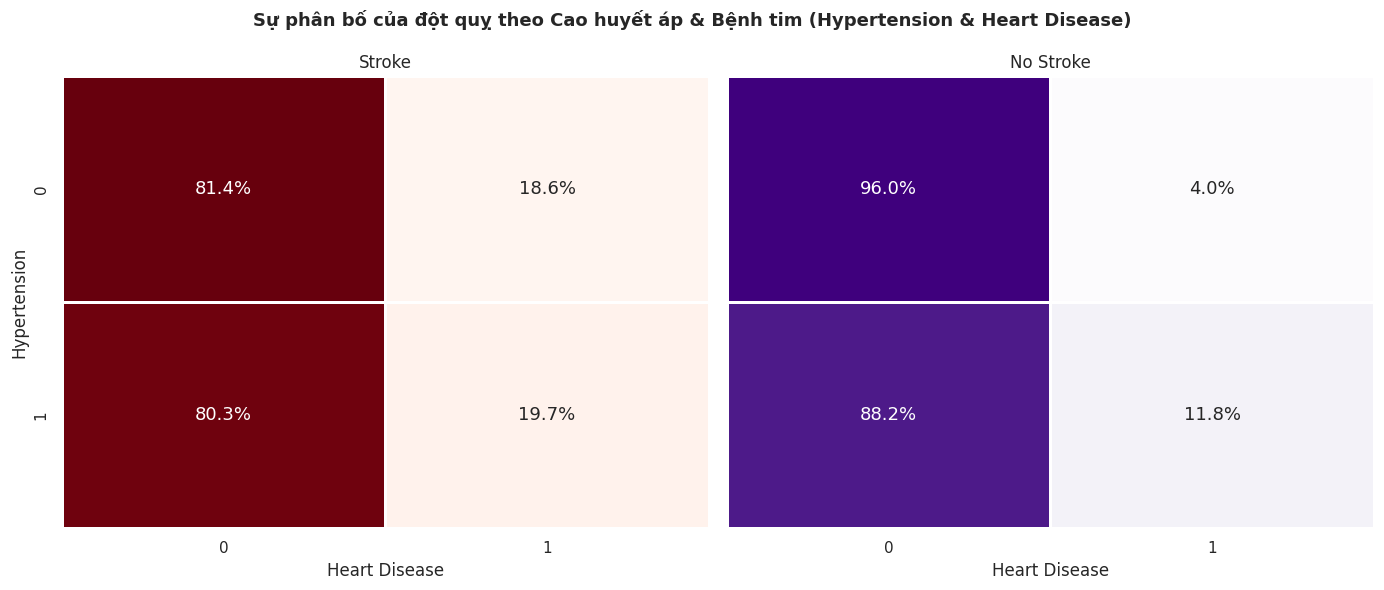

In [ ]:
stroke_ct_health = pd.crosstab(df_stroke['hypertension'], df_stroke['heart_disease'], normalize='index')
no_stroke_ct_health = pd.crosstab(df_no_stroke['hypertension'], df_no_stroke['heart_disease'], normalize='index')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Sự phân bố của đột quỵ theo Cao huyết áp & Bệnh tim (Hypertension & Heart Disease)', fontsize=13, fontweight='bold')

sns.heatmap(stroke_ct_health, annot=True, fmt='.1%', cmap='Reds', ax=axes[0],
            cbar=False, linewidths=1, annot_kws={"size": 13})
axes[0].set_title('Stroke')
axes[0].set_ylabel('Hypertension')
axes[0].set_xlabel('Heart Disease')

sns.heatmap(no_stroke_ct_health, annot=True, fmt='.1%', cmap='Purples', ax=axes[1],
            cbar=False, linewidths=1, annot_kws={"size": 13})
axes[1].set_title('No Stroke')
axes[1].set_ylabel('')
axes[1].set_yticks([])
axes[1].set_xlabel('Heart Disease')

plt.tight_layout()
plt.show()

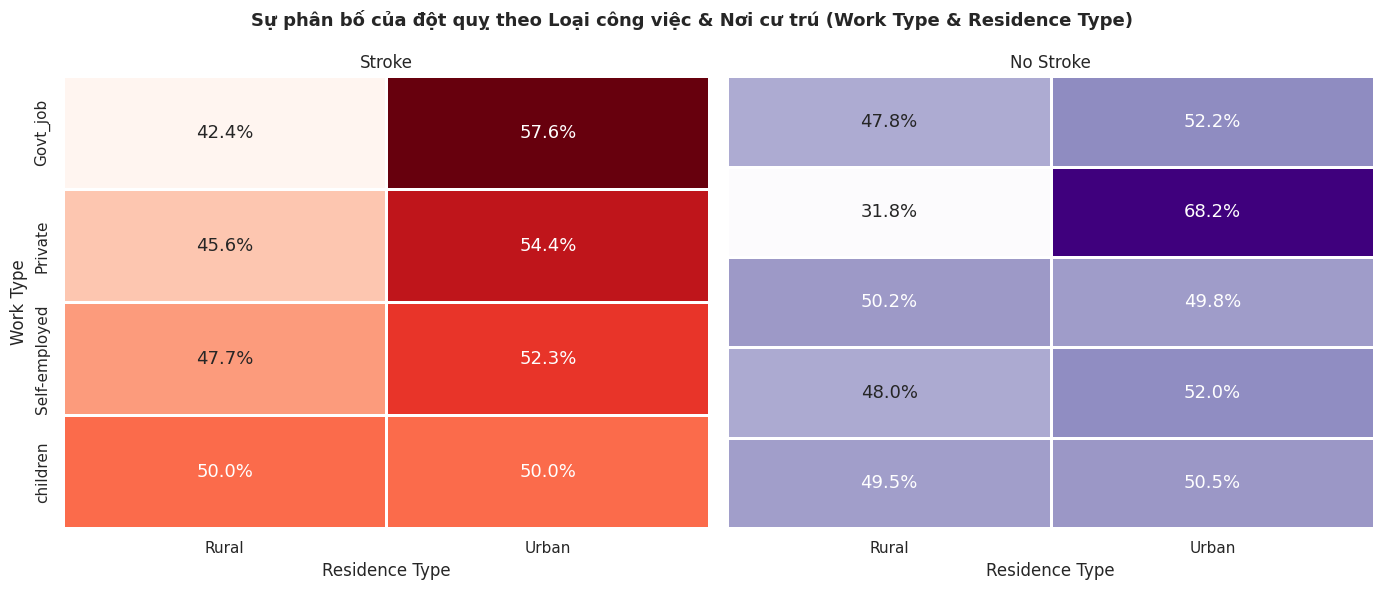

In [ ]:
stroke_ct_work_res = pd.crosstab(df_stroke['work_type'], df_stroke['Residence_type'], normalize='index')
no_stroke_ct_work_res = pd.crosstab(df_no_stroke['work_type'], df_no_stroke['Residence_type'], normalize='index')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Sự phân bố của đột quỵ theo Loại công việc & Nơi cư trú (Work Type & Residence Type)', fontsize=13, fontweight='bold')

sns.heatmap(stroke_ct_work_res, annot=True, fmt='.1%', cmap='Reds', ax=axes[0],
            cbar=False, linewidths=1, annot_kws={"size": 13})
axes[0].set_title('Stroke')
axes[0].set_ylabel('Work Type')
axes[0].set_xlabel('Residence Type')

sns.heatmap(no_stroke_ct_work_res, annot=True, fmt='.1%', cmap='Purples', ax=axes[1],
            cbar=False, linewidths=1, annot_kws={"size": 13})
axes[1].set_title('No Stroke')
axes[1].set_ylabel('')
axes[1].set_yticks([])
axes[1].set_xlabel('Residence Type')

plt.tight_layout()
plt.show()

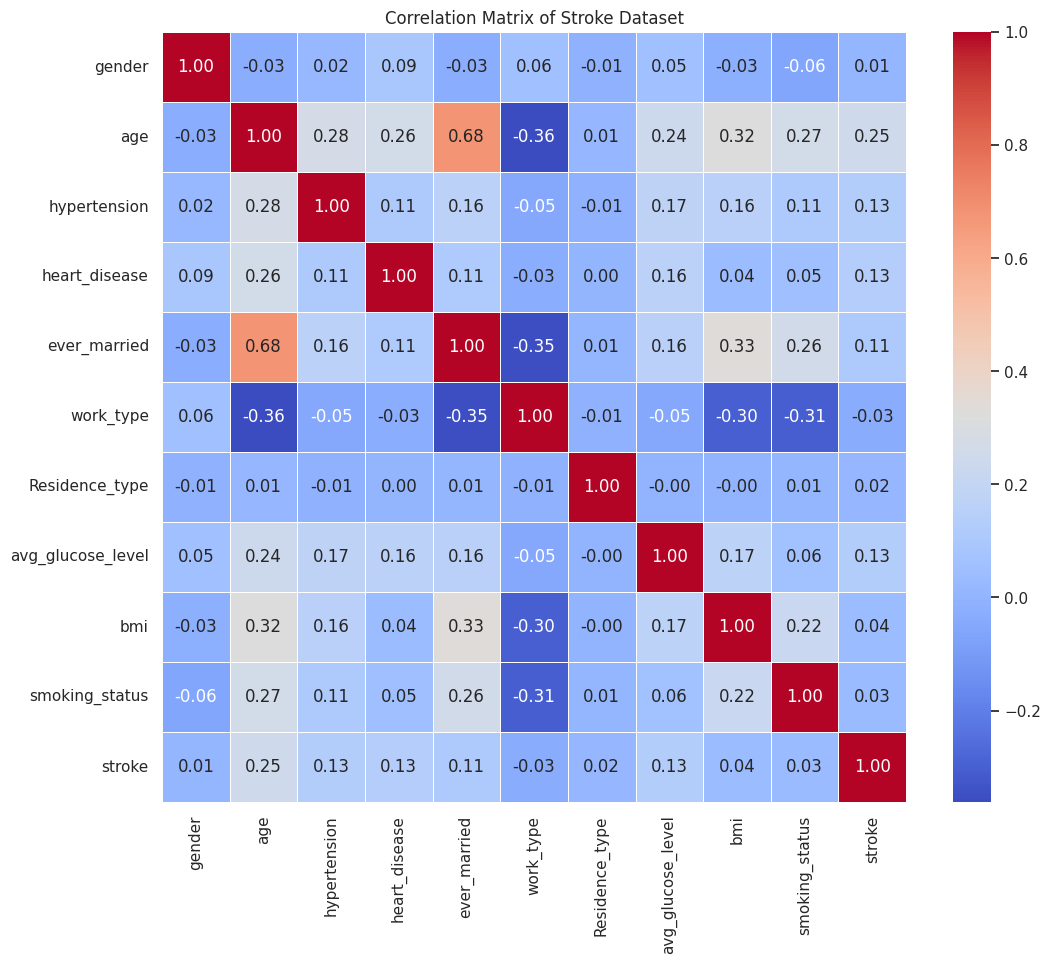

In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# 3. Tính toán ma trận tương quan
corr_matrix = df.corr()

# 4. Vẽ biểu đồ nhiệt (Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Stroke Dataset')
plt.show()